In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import time
import matplotlib.pyplot as plt
import joblib

from river import ensemble
from river import metrics
from river import preprocessing
from river import forest

In [ ]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path("../data/filtered") / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)

In [ ]:
df = df[['mac_dl_brate']]

target = 'mac_dl_brate'

num_lags = 2
for lag in range(1, num_lags + 1):
    df[f'{target}_lag_{lag}'] = df[target].shift(lag)

df.dropna(inplace=True)

In [ ]:
horizon = 96
split_point = int(len(df) * 0.8)
test_start_time = df.index[split_point]


model = preprocessing.StandardScaler() | forest.ARFRegressor(seed=42)
records = []

total_training_time = 0.0
total_inference_time = 0.0
test_prediction_count = 0
train_sample_count = 0

for t in range(horizon, len(df) - horizon):

    #Prediction
    if df.index[t] >= test_start_time:
        start_pred = time.time()

    for h in range(1, horizon + 1):
        idx = t + h
        row = df.iloc[idx]
        x = {col: row[col] for col in df.columns if col != 'mac_dl_brate'}
        pred = model.predict_one(x)
        actual = row['mac_dl_brate']
        timestamp = df.index[idx]
        source_t = df.index[t]

        records.append({
            'timestamp': timestamp,
            'source_t': source_t,
            'horizon': h,
            'actual': actual,
            'prediction': pred
        })

    if df.index[t] >= test_start_time:
        end_pred = time.time()
        total_inference_time += (end_pred - start_pred)
        test_prediction_count += horizon  

    #Training timing 
    if df.index[t + 1] < test_start_time:
        start_train = time.time()
        row = df.iloc[t + 1]
        x = {col: row[col] for col in df.columns if col != 'mac_dl_brate'}
        y = row['mac_dl_brate']
        model.learn_one(x, y)
        end_train = time.time()
        total_training_time += (end_train - start_train)
        train_sample_count += 1

df_forecasts = pd.DataFrame(records)

print(f"Total training time: {total_training_time:.2f} seconds")
if train_sample_count > 0:
    avg_training_time = total_training_time / train_sample_count
    print(f"Average training time per sample: {avg_training_time:.6f} seconds")

print(f"Total inference time (test set): {total_inference_time:.2f} seconds")
if test_prediction_count > 0:
    avg_inference_time = total_inference_time / test_prediction_count
    print(f"Average inference time per test sample: {avg_inference_time:.6f} seconds")

Total training time: 170.60 seconds
Average training time per sample: 0.006523 seconds
Total inference time (test set): 369.54 seconds
Average inference time per test sample: 0.000595 seconds


In [ ]:
df_test_forecasts = df_forecasts[df_forecasts['source_t'] >= test_start_time]

df_agg = df_test_forecasts.groupby('source_t').agg({
    'actual': 'mean',
    'prediction': 'mean'
}).dropna().reset_index()

train_actuals = df_forecasts[df_forecasts['source_t'] < test_start_time]['actual']
scaler = MinMaxScaler()
scaler.fit(train_actuals.values.reshape(-1, 1))

In [8]:
actual_scaled = scaler.transform(df_test_forecasts['actual'].values.reshape(-1, 1)).flatten()
pred_scaled = scaler.transform(df_test_forecasts['prediction'].values.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(actual_scaled, pred_scaled))
mae = mean_absolute_error(actual_scaled, pred_scaled)

print(f"Scaled RMSE: {rmse:.4f}")
print(f"Scaled MAE: {mae:.4f}")

Scaled RMSE: 0.0269
Scaled MAE: 0.0189


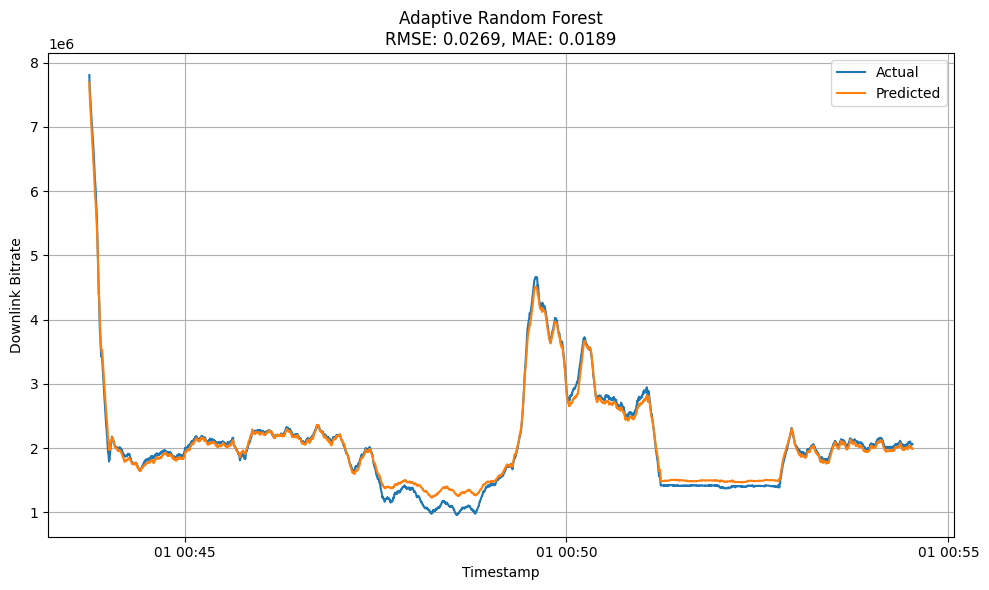

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(df_agg['source_t'], df_agg['actual'], label='Actual')
plt.plot(df_agg['source_t'], df_agg['prediction'], label='Predicted')
plt.title(f'Adaptive Random Forest\nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "ARF",
    "setting": "univariate",
    "dataset": "youtube_static",
    "rmse": rmse,
    "mae": mae,
}])

metrics_file = results_dir / "arf_uni_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)